**Group:** Diego McGrath, Aeden Rask

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import uniform, norm, ks_1samp
from scipy.stats import expon, beta

rng = np.random.default_rng(0)

def ecdf(x):
    x = np.sort(x)
    return x, np.arange(1, len(x) + 1) / len(x)

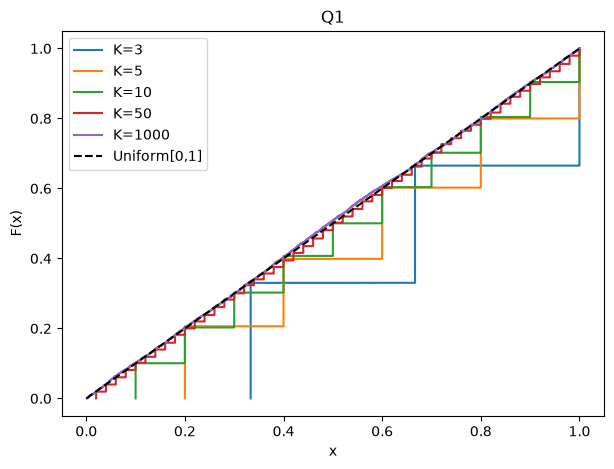

In [18]:
n = 5_000

fig, ax = plt.subplots(figsize=(7, 5))
for K in [3, 5, 10, 50, 1000]:
    draws = rng.integers(1, K + 1, size=n) / K
    x, y = ecdf(draws)
    ax.step(x, y, where="post", label=f"K={K}")

g = np.linspace(0, 1, 200)
ax.plot(g, uniform.cdf(g, loc=0, scale=1), "k--", label="Uniform[0,1]")
ax.set_title("Q1")
ax.set_xlabel("x")
ax.set_ylabel("F(x)")
ax.legend()
plt.show()

**Q1**: Uniform

n=1: KS distance from N(0,1) = 0.058
n=2: KS distance from N(0,1) = 0.023
n=8: KS distance from N(0,1) = 0.021
n=32: KS distance from N(0,1) = 0.009


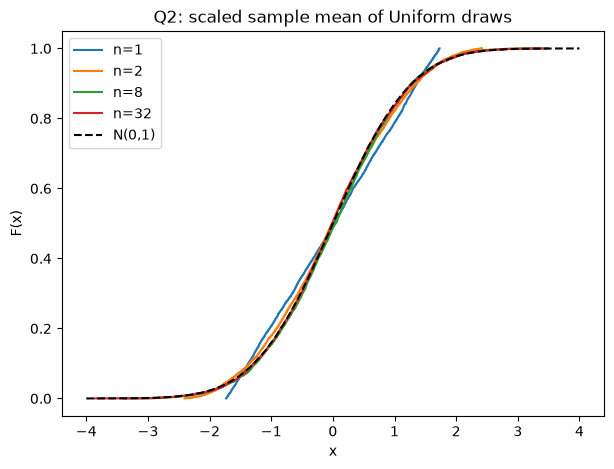

In [ ]:
def q2_sample(n, b=5_000):
    data = rng.uniform(-np.sqrt(3), np.sqrt(3), size=(b, n))
    return np.sqrt(n) * data.mean(axis=1)

grid = np.linspace(-4, 4, 400)

fig, ax = plt.subplots(figsize=(7, 5))
for n in [1, 2, 8, 32]:
    s = q2_sample(n)
    x, y = ecdf(s)
    ax.step(x, y, where="post", label=f"n={n}")
    print(f"n={n}: KS distance from N(0,1) = {ks_1samp(s, norm.cdf).statistic:.3f}")

ax.plot(grid, norm.cdf(grid), "k--", label="N(0,1)")
ax.set_title("Q2: scaled sample mean of Uniform draws")
ax.set_xlabel("x")
ax.set_ylabel("F(x)")
ax.legend()
plt.show()

**Q2**: Normal

In [19]:
def q3_sample(n, p, b=5_000):
    heads = rng.binomial(n, p, size=b)
    return (heads - n * p) / np.sqrt(n * p * (1 - p))

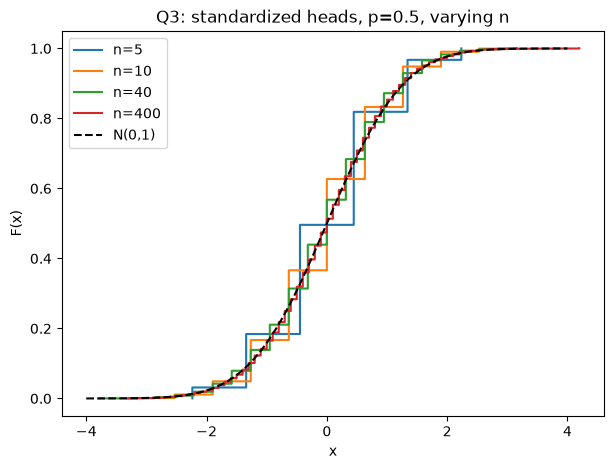

In [20]:
grid = np.linspace(-4, 4, 400)

fig, ax = plt.subplots(figsize=(7, 5))
for n in [5, 10, 40, 400]:
    x, y = ecdf(q3_sample(n, 0.5))
    ax.step(x, y, where="post", label=f"n={n}")

ax.plot(grid, norm.cdf(grid), "k--", label="N(0,1)")
ax.set_title("Q3: standardized heads, p=0.5, varying n")
ax.set_xlabel("x")
ax.set_ylabel("F(x)")
ax.legend()
plt.show()

p=0.9: KS distance from N(0,1) = 0.127
p=0.5: KS distance from N(0,1) = 0.064
p=0.2: KS distance from N(0,1) = 0.095
p=0.05: KS distance from N(0,1) = 0.179
p=0.01: KS distance from N(0,1) = 0.406


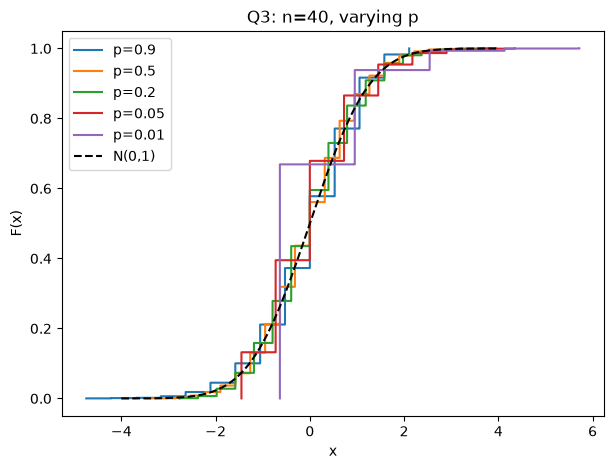

In [33]:
fig, ax = plt.subplots(figsize=(7, 5))
for p in [0.9, 0.5, 0.2, 0.05, 0.01]:
    s = q3_sample(40, p)
    x, y = ecdf(s)
    ax.step(x, y, where="post", label=f"p={p}")
    print(f"p={p}: KS distance from N(0,1) = {ks_1samp(s, norm.cdf).statistic:.3f}")

ax.plot(grid, norm.cdf(grid), "k--", label="N(0,1)")
ax.set_title("Q3: n=40, varying p")
ax.set_xlabel("x")
ax.set_ylabel("F(x)")
ax.legend()
plt.show()

**Q3**: Normal, when adjusting p, the standardization keeps the mean at 0 and the variance at 1 for any p, but the approximation gets worse as p moves toward 0 or 1.

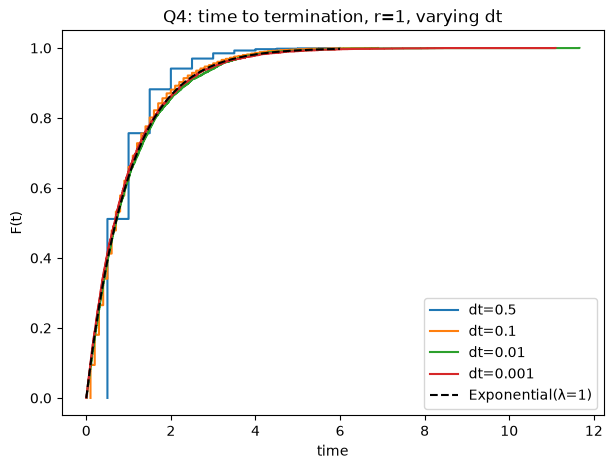

In [22]:
def q4_sample(r, dt, n=5_000):
    periods = rng.geometric(r * dt, size=n)
    return periods * dt

r = 1.0
grid = np.linspace(0, 6, 400)

fig, ax = plt.subplots(figsize=(7, 5))
for dt in [0.5, 0.1, 0.01, 0.001]:
    x, y = ecdf(q4_sample(r, dt))
    ax.step(x, y, where="post", label=f"dt={dt}")

ax.plot(grid, expon.cdf(grid, scale=1/r), "k--", label="Exponential(λ=1)")
ax.set_title("Q4: time to termination, r=1, varying dt")
ax.set_xlabel("time")
ax.set_ylabel("F(t)")
ax.legend()
plt.show()

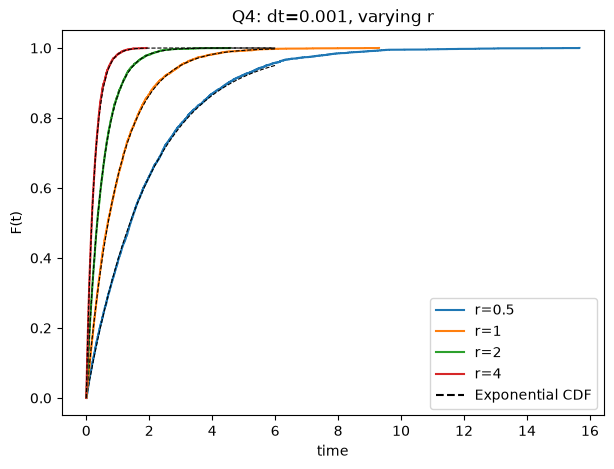

In [23]:
grid = np.linspace(0, 6, 400)

fig, ax = plt.subplots(figsize=(7, 5))
for r in [0.5, 1, 2, 4]:
    x, y = ecdf(q4_sample(r, dt=0.001))
    ax.step(x, y, where="post", label=f"r={r}")
    ax.plot(grid, expon.cdf(grid, scale=1/r), "k--", lw=0.8)

ax.plot([], [], "k--", label="Exponential CDF")
ax.set_title("Q4: dt=0.001, varying r")
ax.set_xlabel("time")
ax.set_ylabel("F(t)")
ax.legend()
plt.show()

**Q4**: Exponential, r only rescales the time axis. Larger r means earlier terminations and a faster-rising CDF. The mean time to termination is 1/r